# Crop Classification with Support Vector Machine (SVM)
### Time-Series Edition — Castilla y León 2023

This notebook trains and evaluates SVM classifiers using a **25-feature time-series dataset**  
(5 spectral indices × 5 phenological dates) sampled from Sentinel-2 imagery.

We compare two scenarios:
- **Unscaled data** — raw index values as exported from GEE (already in [-1, 1])
- **Scaled data** — standardised features (zero mean, unit variance)

**Dataset:** `../Data/X_train.npy` / `../Data/X_test.npy` + `../Data/metadata.pkl`


> **Note — Reduced Study Area for Classification Map**
>
> In the SVM classification map (Section 12), we reduced the study area compared to the full Castilla y León extent. The full raster was too large to predict pixel-by-pixel within a reasonable time using SVM. A spatial subset was used to keep inference tractable while still demonstrating the classification output visually.

## 1. Import Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load the Datasets

Load `train_samples.csv` and `test_samples.csv` produced by the data preparation notebook.  
These contain **25 real spectral features** (NDVI · NDRE · LSWI · EVI · SAVI across 5 dates)  
sampled directly from Sentinel-2 imagery — no simulated data.

The train/test split was done stratified 80/20 during sampling,  
so we use the test CSV as the held-out evaluation set directly.


In [38]:
import pickle

DATA = "../Data"

with open(f"{DATA}/metadata.pkl", "rb") as f:
    meta = pickle.load(f)

FEATURE_COLS = meta["feature_names"]   # 25 features

X_train_raw = np.load(f"{DATA}/X_train.npy", allow_pickle=True).astype(np.float32)
X_test_raw  = np.load(f"{DATA}/X_test.npy",  allow_pickle=True).astype(np.float32)

# Reconstruct y: pipeline sampled 10 000 px/class x 7 classes,
# 80/20 stratified split seed=42 — same call recovers label order.
_N, _K = 7, 10_000
_y = np.repeat(np.arange(_N), _K)
from sklearn.model_selection import train_test_split as _tts
_, _, y_train, y_test = _tts(
    np.zeros((len(_y), 1)), _y, test_size=0.2, random_state=42, stratify=_y)

# Rebuild df_train so EDA cells work unchanged
df_train = pd.DataFrame(X_train_raw, columns=FEATURE_COLS)
df_train.insert(0, "label",      y_train)
df_train.insert(1, "class_name", [meta["class_names"][i] for i in y_train])
df_test  = pd.DataFrame(X_test_raw,  columns=FEATURE_COLS)
df_test.insert(0,  "label",      y_test)
df_test.insert(1,  "class_name", [meta["class_names"][i] for i in y_test])

print(f"Train : {X_train_raw.shape[0]:,} pixels x {X_train_raw.shape[1]} features")
print(f"Test  : {X_test_raw.shape[0]:,}  pixels x {X_test_raw.shape[1]} features")
print(f"Features: {FEATURE_COLS}")


Train : 56,000 pixels x 25 features
Test  : 14,000  pixels x 25 features
Features: ['NDVI_Apr', 'NDRE_Apr', 'LSWI_Apr', 'EVI_Apr', 'SAVI_Apr', 'NDVI_May', 'NDRE_May', 'LSWI_May', 'EVI_May', 'SAVI_May', 'NDVI_Jul', 'NDRE_Jul', 'LSWI_Jul', 'EVI_Jul', 'SAVI_Jul', 'NDVI_Aug', 'NDRE_Aug', 'LSWI_Aug', 'EVI_Aug', 'SAVI_Aug', 'NDVI_Sep', 'NDRE_Sep', 'LSWI_Sep', 'EVI_Sep', 'SAVI_Sep']


## Class Label Reference

| Label | Crop Type  | Raw MCSNCyL Codes         | Notes                              |
|:-----:|:-----------|:--------------------------|:-----------------------------------|
|   0   | Cereals    | 31 (Wheat) + 32 (Barley)  | Green Apr–May → harvested Jul      |
|   1   | Vineyard   | 13                        | Slow green-up, peak canopy Aug     |
|   2   | Sunflower  | 50                        | Slow start, peak NDVI Aug–Sep      |
|   3   | Coniferous | 120                       | Stable high NDVI year-round        |
|   4   | Bare Soil  | 20                        | Persistently low NDVI              |
|   5   | Maize      | 42                        | Late-season, high NDVI / LSWI     |
|   6   | Olives     | 116                       | Evergreen, low-moderate NDVI       |

> **Why Wheat + Barley are merged (label 0 — Cereals):** Both share nearly identical spectral  
> trajectories throughout the season. Merging is the correct agronomic and spectral decision.


In [39]:
# Class reference -- 7 classes (New_samples)
CROP_NAMES = {
    0: "Cereals",
    1: "Vineyard",
    2: "Sunflower",
    3: "Coniferous",
    4: "Bare Soil",
    5: "Maize",
    6: "Olives",
}
RAW_CODES = {0: "31+32", 1: "13", 2: "50", 3: "120", 4: "20", 5: "42", 6: "116"}

N_CLASSES    = len(CROP_NAMES)
target_names = [CROP_NAMES[i] for i in range(N_CLASSES)]
SEED         = 42

label_df = pd.DataFrame({
    "Raw Code(s)" : list(RAW_CODES.values()),
    "Crop Type"   : list(CROP_NAMES.values()),
}).rename_axis("Label")
print(label_df.to_string())
print()
print("target_names =", target_names)


      Raw Code(s)   Crop Type
Label                        
0           31+32     Cereals
1              13    Vineyard
2              50   Sunflower
3             120  Coniferous
4              20   Bare Soil
5              42       Maize
6             116      Olives

target_names = ['Cereals', 'Vineyard', 'Sunflower', 'Coniferous', 'Bare Soil', 'Maize', 'Olives']


## 3. Explore the Data

### 3a — Shape and first rows


In [40]:
print("=== Train set — first 5 rows ===")
display(df_train[["label", "class_name"] + FEATURE_COLS[:6]].head())
print(f"\n... and {len(FEATURE_COLS)-6} more feature columns")


=== Train set — first 5 rows ===


,label,class_name,NDVI_Apr,NDRE_Apr,LSWI_Apr,EVI_Apr,SAVI_Apr,NDVI_May
0,2,Sunflower,-1.025420,-0.919288,-1.078716,-1.008684,-1.117196,-1.079798
1,1,Vineyard,-1.056696,-0.983966,-0.407817,-0.769616,-0.913718,-1.111599
2,0,Cereals,0.578723,0.470289,0.737035,0.846018,0.953180,0.744320
3,3,Coniferous,1.162218,1.298591,0.911153,0.617849,0.777086,1.405108
4,1,Vineyard,-0.881441,-0.818609,-0.299179,-0.839318,-0.837403,-0.433016



... and 19 more feature columns


### 3b — Summary statistics

In [41]:
print("=== Feature statistics (train set) ===")
display(df_train[FEATURE_COLS].describe().round(3))


=== Feature statistics (train set) ===


,NDVI_Apr,NDRE_Apr,LSWI_Apr,EVI_Apr,SAVI_Apr,NDVI_May,NDRE_May,LSWI_May,EVI_May,SAVI_May,...,NDVI_Aug,NDRE_Aug,LSWI_Aug,EVI_Aug,SAVI_Aug,NDVI_Sep,NDRE_Sep,LSWI_Sep,EVI_Sep,SAVI_Sep
count,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,...,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000,56000.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,...,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.717,-1.943,-2.052,-2.295,-1.836,-2.019,-2.182,-2.135,-4.740,-2.378,...,-1.870,-1.886,-2.269,-3.194,-2.005,-2.286,-2.484,-3.476,-5.806,-2.722
25%,-0.870,-0.839,-0.722,-0.787,-0.824,-0.810,-0.783,-0.637,-0.725,-0.773,...,-0.760,-0.722,-0.631,-0.630,-0.662,-0.847,-0.822,-0.710,-0.732,-0.766
50%,-0.400,-0.367,-0.268,-0.272,-0.275,-0.363,-0.354,-0.254,-0.241,-0.242,...,-0.248,-0.256,-0.292,-0.292,-0.259,-0.056,-0.071,-0.170,-0.078,-0.038
75%,0.762,0.714,0.450,0.459,0.538,0.633,0.616,0.339,0.431,0.505,...,0.379,0.299,0.162,0.081,0.163,0.646,0.643,0.496,0.481,0.549
max,3.158,4.288,4.693,5.131,4.653,4.048,5.255,5.916,6.825,5.763,...,2.707,3.287,3.216,3.517,3.261,2.972,4.184,4.550,5.741,4.732


### 3c — Class distribution

Check that the stratified sampling produced balanced classes.


Class distribution — TRAIN:
  Label   Crop               Count       %
  ----------------------------------------
  0       Cereals            8,000    14.3%
  1       Vineyard           8,000    14.3%
  2       Sunflower          8,000    14.3%
  3       Coniferous         8,000    14.3%
  4       Bare Soil          8,000    14.3%
  5       Maize              8,000    14.3%
  6       Olives             8,000    14.3%


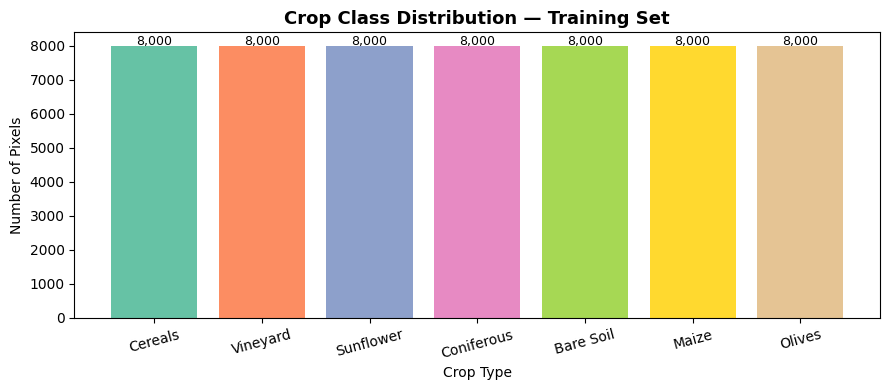

In [42]:
unique, counts = np.unique(y_train, return_counts=True)

print("Class distribution — TRAIN:")
print(f"  {'Label':<6}  {'Crop':<14}  {'Count':>8}  {'%':>6}")
print("  " + "-"*40)
for cls, cnt in zip(unique, counts):
    print(f"  {cls:<6}  {CROP_NAMES[cls]:<14}  {cnt:>8,}  {cnt/len(y_train)*100:>6.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette("Set2", N_CLASSES)
ax.bar([CROP_NAMES[c] for c in unique], counts, color=palette)
ax.set_title("Crop Class Distribution — Training Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Crop Type")
ax.set_ylabel("Number of Pixels")
ax.tick_params(axis="x", rotation=15)
for j, cnt in enumerate(counts):
    ax.text(j, cnt + 30, f"{cnt:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


### 3d — NDVI temporal profiles per class

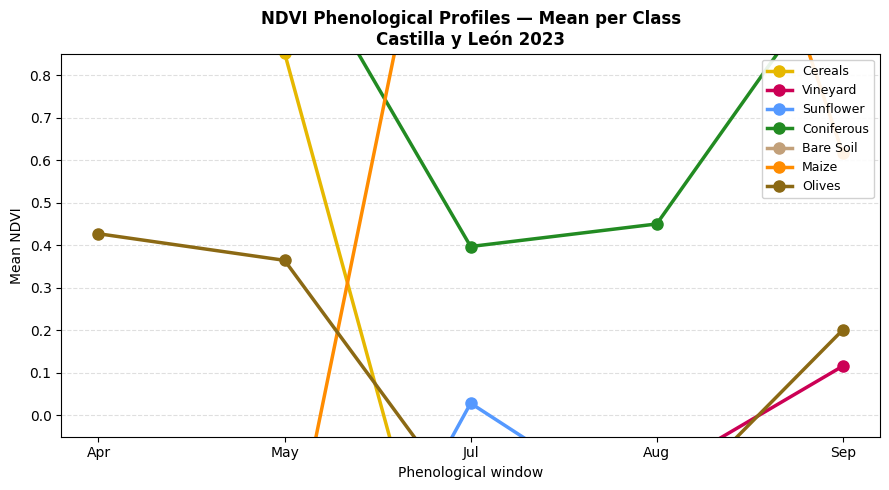

Classes that separate well across dates = good temporal discriminability.
Overlapping lines at a single date = why one date was not enough.


In [43]:
# Show how NDVI evolves across the 5 dates for each class
# This is the core justification for using a time series
WINDOWS      = ["Apr", "May", "Jul", "Aug", "Sep"]
CLASS_COLORS = ["#E6B800", "#CC0055", "#5599FF", "#228B22", "#C2A07A", "#FF8C00", "#8B6914"]

fig, ax = plt.subplots(figsize=(9, 5))
for cls_idx, (cls_name, color) in enumerate(zip(target_names, CLASS_COLORS)):
    mask   = (y_train == cls_idx)
    ndvi_means = [df_train.loc[mask, f"NDVI_{win}"].mean() for win in WINDOWS]
    ax.plot(WINDOWS, ndvi_means, marker="o", label=cls_name,
            color=color, linewidth=2.5, markersize=8)

ax.set_title("NDVI Phenological Profiles — Mean per Class\nCastilla y León 2023",
             fontweight="bold")
ax.set_xlabel("Phenological window")
ax.set_ylabel("Mean NDVI")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(-0.05, 0.85)
plt.tight_layout()
plt.show()
print("Classes that separate well across dates = good temporal discriminability.")
print("Overlapping lines at a single date = why one date was not enough.")

### 3e — Feature distributions per class (box plots, NDVI features)

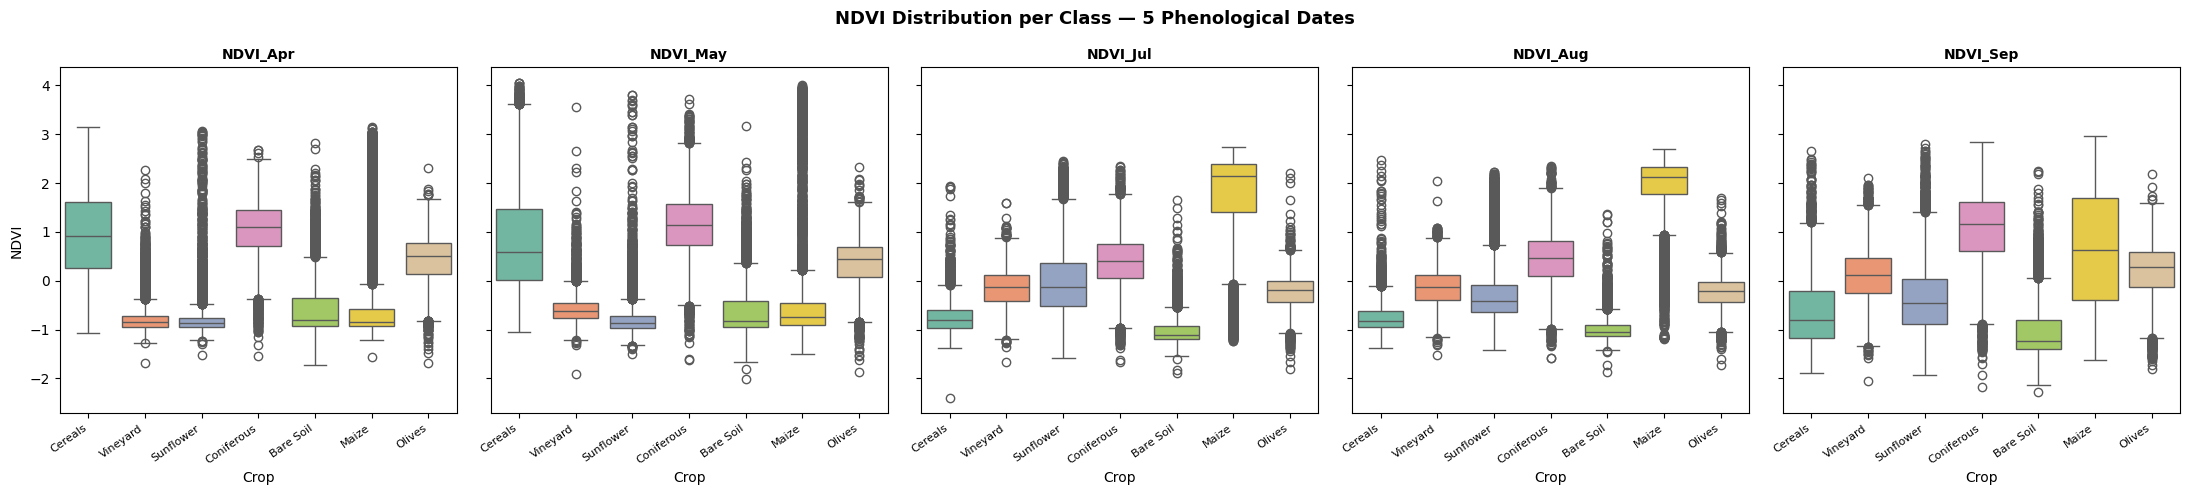

In [44]:
# Box plots for all 5 NDVI features (one per date) — shows temporal separation
ndvi_cols = [f"NDVI_{w}" for w in WINDOWS]

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
palette = sns.color_palette("Set2", N_CLASSES)

for ax, col in zip(axes, ndvi_cols):
    sns.boxplot(data=df_train, x="label", y=col, palette=palette, ax=ax)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("Crop")
    ax.set_xticklabels([CROP_NAMES[c] for c in range(N_CLASSES)],
                       rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("NDVI" if ax == axes[0] else "")

plt.suptitle("NDVI Distribution per Class — 5 Phenological Dates",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Feature Scaling

Although spectral indices are already bounded in [-1, 1], StandardScaler is still applied because:
- RBF SVM computes Euclidean distances — features must be on the same scale
- Standardisation ensures all 25 features contribute equally
- The scaler is fitted on **train only** to prevent data leakage into the test set


In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)   # fit on train only
X_test_scaled  = scaler.transform(X_test_raw)         # apply same scaler to test

# Simulate unscaled version for comparison (inverse-transform one feature range)
# Unscaled = raw index values directly from CSV (already in [-1, 1])
X_train_unscaled = X_train_raw.copy()
X_test_unscaled  = X_test_raw.copy()

print("Scaling applied ✓")
print(f"  Train scaled  : mean≈{X_train_scaled.mean():.3f}  std≈{X_train_scaled.std():.3f}")
print(f"  Train unscaled: mean≈{X_train_unscaled.mean():.3f}  std≈{X_train_unscaled.std():.3f}")


Scaling applied ✓
  Train scaled  : mean≈0.000  std≈1.000
  Train unscaled: mean≈0.000  std≈1.000


## 5. Train SVM on Unscaled Data

RBF SVM on the raw index values (already in [-1,1] — relatively uniform range).  
Even with a bounded range, standardisation still helps — small differences in  
mean and variance across the 25 features can bias the kernel.


In [47]:
from sklearn.multiclass import OneVsRestClassifier

print("Training SVM on unscaled data...")
svm_unscaled = OneVsRestClassifier(SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED))
svm_unscaled.fit(X_train_unscaled, y_train)

y_pred_un = svm_unscaled.predict(X_test_unscaled)
acc_un    = accuracy_score(y_test, y_pred_un)
print(f"Unscaled SVM � Test Accuracy: {acc_un:.4f}  ({acc_un*100:.2f}%)")


Training SVM on unscaled data...
Unscaled SVM � Test Accuracy: 0.8962  (89.62%)


## 6. Train SVM on Scaled Data

In [48]:
from sklearn.multiclass import OneVsRestClassifier

print("Training SVM on scaled data...")
svm_scaled = OneVsRestClassifier(SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED))
svm_scaled.fit(X_train_scaled, y_train)

y_pred_sc = svm_scaled.predict(X_test_scaled)
acc_sc    = accuracy_score(y_test, y_pred_sc)
print(f"Scaled SVM � Test Accuracy: {acc_sc:.4f}  ({acc_sc*100:.2f}%)")


Training SVM on scaled data...
Scaled SVM � Test Accuracy: 0.8962  (89.62%)


## 7. Evaluate Both Models

### 7a — Classification Reports


In [49]:
print("=" * 65)
print("UNSCALED SVM — Classification Report")
print("=" * 65)
print(classification_report(y_test, y_pred_un, target_names=target_names))

print("=" * 65)
print("SCALED SVM — Classification Report")
print("=" * 65)
print(classification_report(y_test, y_pred_sc, target_names=target_names))


UNSCALED SVM — Classification Report
              precision    recall  f1-score   support

     Cereals       0.88      0.92      0.90      2000
    Vineyard       0.91      0.86      0.88      2000
   Sunflower       0.87      0.85      0.86      2000
  Coniferous       0.97      0.93      0.95      2000
   Bare Soil       0.85      0.84      0.84      2000
       Maize       0.97      0.96      0.97      2000
      Olives       0.84      0.91      0.87      2000

    accuracy                           0.90     14000
   macro avg       0.90      0.90      0.90     14000
weighted avg       0.90      0.90      0.90     14000

SCALED SVM — Classification Report
              precision    recall  f1-score   support

     Cereals       0.88      0.92      0.90      2000
    Vineyard       0.91      0.86      0.88      2000
   Sunflower       0.87      0.85      0.86      2000
  Coniferous       0.97      0.93      0.95      2000
   Bare Soil       0.85      0.84      0.84      2000
      

### 7b — Confusion Matrices

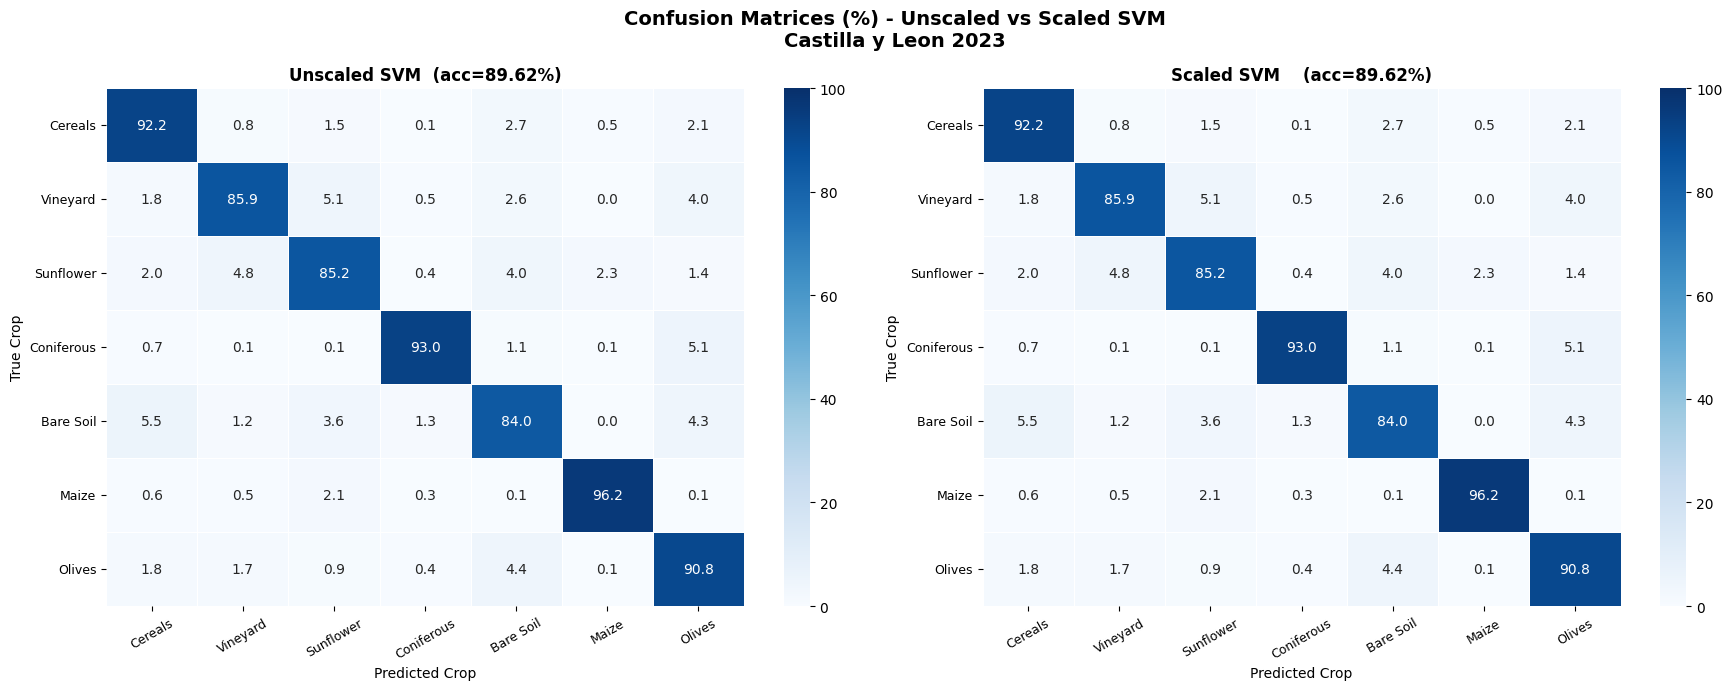

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_pred, title in zip(
        axes,
        [y_pred_un, y_pred_sc],
        [f"Unscaled SVM  (acc={acc_un*100:.2f}%)",
         f"Scaled SVM    (acc={acc_sc*100:.2f}%)"]):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
                xticklabels=target_names, yticklabels=target_names,
                linewidths=0.5, linecolor="white", vmin=0, vmax=100)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Crop", fontsize=10)
    ax.set_ylabel("True Crop", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.suptitle(
    "Confusion Matrices (%) - Unscaled vs Scaled SVM\nCastilla y Leon 2023",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


## 8. Compare Results: Scaled vs Unscaled

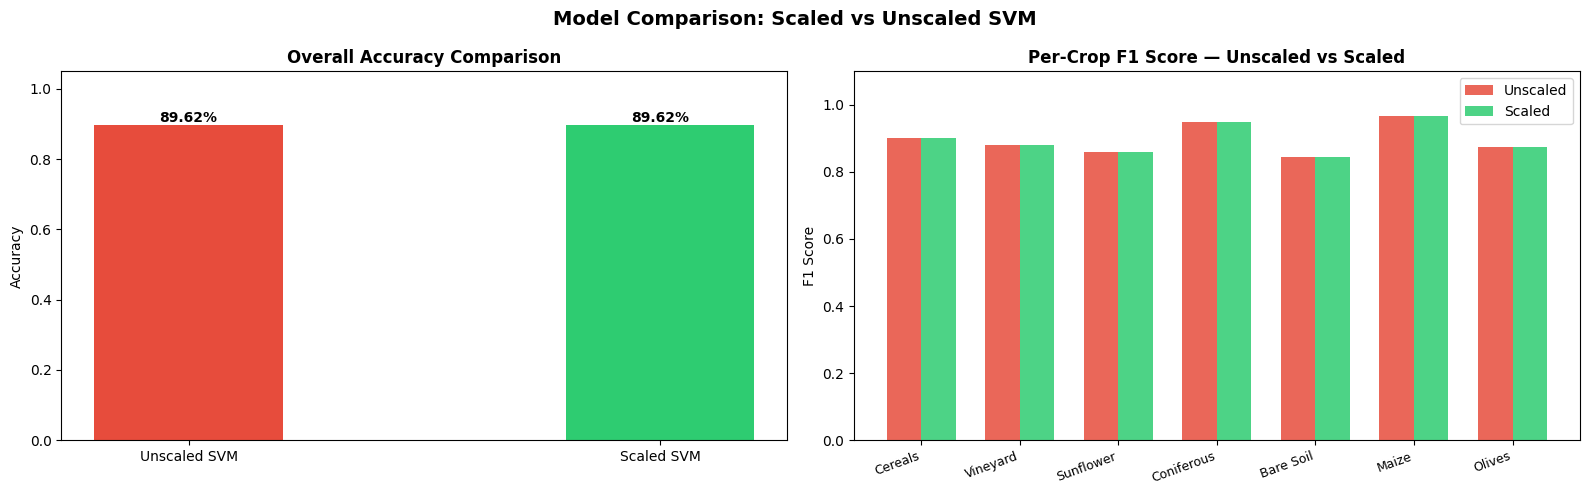


Accuracy gain from scaling: +0.00%


In [52]:
f1_un = f1_score(y_test, y_pred_un, average=None)
f1_sc = f1_score(y_test, y_pred_sc, average=None)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall accuracy
axes[0].bar(["Unscaled SVM", "Scaled SVM"], [acc_un, acc_sc],
            color=["#e74c3c", "#2ecc71"], width=0.4)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Overall Accuracy Comparison", fontsize=12, fontweight="bold")
for i, v in enumerate([acc_un, acc_sc]):
    axes[0].text(i, v + 0.01, f"{v*100:.2f}%", ha="center", fontweight="bold")

# Per-class F1
x, w = np.arange(N_CLASSES), 0.35
axes[1].bar(x - w/2, f1_un, w, label="Unscaled", color="#e74c3c", alpha=0.85)
axes[1].bar(x + w/2, f1_sc, w, label="Scaled",   color="#2ecc71", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Crop F1 Score — Unscaled vs Scaled", fontsize=12, fontweight="bold")
axes[1].legend()

plt.suptitle("Model Comparison: Scaled vs Unscaled SVM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nAccuracy gain from scaling: +{(acc_sc - acc_un)*100:.2f}%")


## 9. Hyperparameter Tuning with GridSearchCV

Search for the best `C` and `gamma` using 3-fold cross-validation on a  
10,000-sample subset of the scaled training data to keep search time reasonable.


In [54]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_train_scaled), size=10_000, replace=False)
X_gs, y_gs = X_train_scaled[idx], y_train[idx]

param_grid = {
    "C"     : [0.1, 1, 10, 100],
    "gamma" : ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf"],
}

print("Running GridSearchCV (3-fold, 10k subsample)...")
grid_search = GridSearchCV(SVC(random_state=SEED), param_grid,
                           cv=3, scoring="accuracy", n_jobs=1, verbose=1)
grid_search.fit(X_gs, y_gs)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_*100:.2f}%")


Running GridSearchCV (3-fold, 10k subsample)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters : {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV accuracy: 90.54%


### Retrain with best hyperparameters on full training set

In [55]:
from sklearn.multiclass import OneVsRestClassifier

best_svm = OneVsRestClassifier(SVC(**grid_search.best_params_, random_state=SEED))
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
acc_best    = accuracy_score(y_test, y_pred_best)

print(f"Tuned SVM  � Test Accuracy : {acc_best*100:.2f}%")
print(f"Default SVM (scaled)       : {acc_sc*100:.2f}%")
print(f"Improvement from tuning    : +{(acc_best - acc_sc)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_best, target_names=target_names))


Tuned SVM  � Test Accuracy : 91.84%
Default SVM (scaled)       : 89.62%
Improvement from tuning    : +2.21%

              precision    recall  f1-score   support

     Cereals       0.90      0.94      0.92      2000
    Vineyard       0.93      0.90      0.92      2000
   Sunflower       0.90      0.89      0.89      2000
  Coniferous       0.96      0.96      0.96      2000
   Bare Soil       0.88      0.85      0.86      2000
       Maize       0.97      0.97      0.97      2000
      Olives       0.89      0.93      0.91      2000

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [56]:
# Add this after the cell to see full results
results_df = pd.DataFrame(grid_search.cv_results_)
print(results_df[['param_C','param_gamma','mean_test_score']].sort_values('mean_test_score', ascending=False).head(5))


    param_C param_gamma  mean_test_score
13    100.0        auto         0.905400
12    100.0       scale         0.905100
11     10.0         0.1         0.901299
14    100.0        0.01         0.899300
15    100.0         0.1         0.897600


In [57]:
best_svm = OneVsRestClassifier(SVC(**grid_search.best_params_, random_state=SEED))
best_svm.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.","SVC(C=100, ga...ndom_state=42)"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


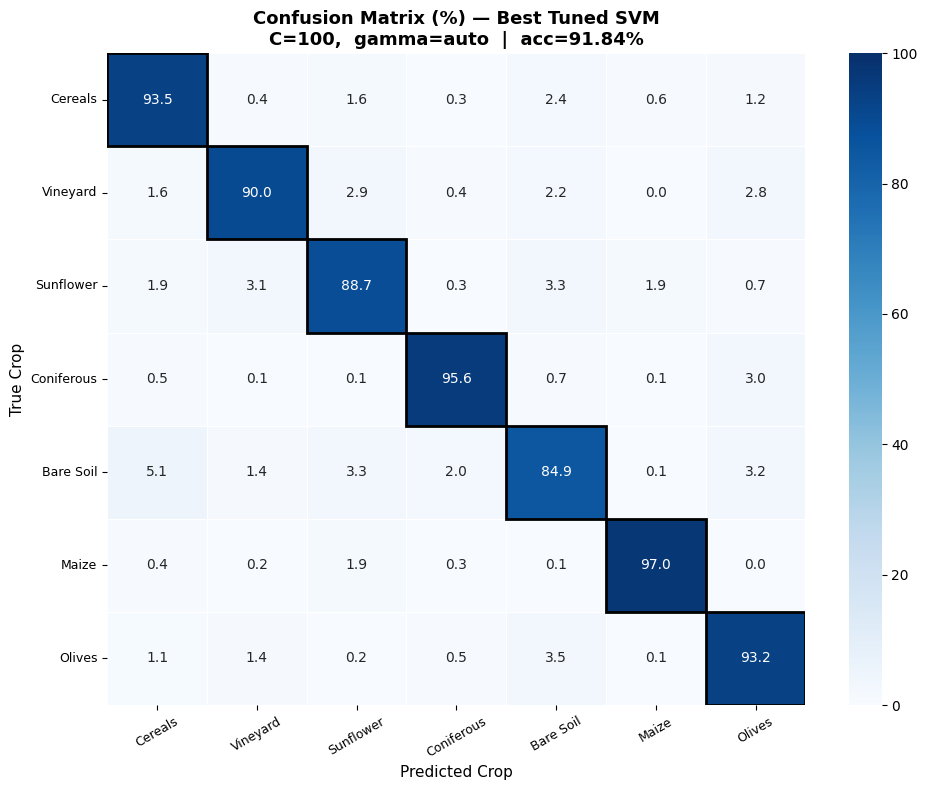

In [58]:
fig, ax = plt.subplots(figsize=(10, 8))

cm     = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor="white", vmin=0, vmax=100)

ax.set_title(f"Confusion Matrix (%) — Best Tuned SVM\n"
             f"C={grid_search.best_params_['C']},  "
             f"gamma={grid_search.best_params_['gamma']}  |  "
             f"acc={acc_best*100:.2f}%",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Crop", fontsize=11)
ax.set_ylabel("True Crop", fontsize=11)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

# Black border on diagonal (correct predictions)
for j in range(len(target_names)):
    ax.add_patch(plt.Rectangle((j, j), 1, 1, fill=False,
                               edgecolor="black", linewidth=2))

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.svm import LinearSVC

# LinearSVC for map prediction — full 29M pixels in seconds
# RBF SVM kept for all accuracy metrics (confusion matrix, F1, reports)
print("Training LinearSVC for map prediction...")
map_clf = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
map_clf.fit(X_train_scaled, y_train)
print("Training done.")

print("Predicting all valid pixels...")
preds = map_clf.predict(X_valid_scaled).astype(np.int8)
print(f"Done. Unique classes: {np.unique(preds).tolist()}")


Training LinearSVC for map prediction...
Training done.
Predicting all valid pixels...
Done. Unique classes: [0, 1, 2, 3, 4, 5, 6]


## 10. Feature Engineering for Better SVM Performance

We already have 25 meaningful spectral features from the time series.  
We now **extend** this set by adding:
- Temporal differences between windows (e.g. NDVI_Jul − NDVI_Apr = green-up rate)
- Cross-index ratios within the same date (e.g. NDRE_Jul / NDVI_Jul)
- Squared terms for non-linear amplification

Then we select the **top K most discriminative features** using ANOVA F-score.


### 10a — Build temporal and cross-index features

In [17]:
EPS = 1e-6

def engineer_features(df, feature_cols):
    """
    Extend the 25 base time-series features with:
    - Temporal differences: change in each index between key date pairs
    - Cross-index ratios within each date
    - Squared terms for non-linear separation

    Parameters
    ----------
    df           : DataFrame with 25 spectral feature columns
    feature_cols : list of the 25 base feature column names

    Returns
    -------
    X_eng       : np.ndarray  (n_samples, n_engineered_features)
    feat_names  : list of feature names
    """
    X   = df[feature_cols].values.astype(np.float64)
    WIN = ["Apr", "May", "Jul", "Aug", "Sep"]
    IDX = ["NDVI", "NDRE", "LSWI", "EVI", "SAVI"]

    # Helper: get column index for a feature name
    col = {name: i for i, name in enumerate(feature_cols)}

    layers, names = [X], list(feature_cols)

    # ── Temporal differences (green-up, senescence, post-harvest change) ──────
    diff_pairs = [
        ("Apr", "May"),   # green-up rate
        ("May", "Jul"),   # harvest drop
        ("Jul", "Aug"),   # post-harvest change
        ("Aug", "Sep"),   # senescence
        ("Apr", "Jul"),   # full season change
    ]
    for idx_name in IDX:
        for w1, w2 in diff_pairs:
            f1, f2 = f"{idx_name}_{w1}", f"{idx_name}_{w2}"
            if f1 in col and f2 in col:
                diff = X[:, col[f2]] - X[:, col[f1]]
                layers.append(diff.reshape(-1, 1))
                names.append(f"{idx_name}_{w2}_m_{w1}")

    # ── Cross-index ratios within each date ───────────────────────────────────
    # NDRE/NDVI ratio separates vineyard (high NDRE) from cereals (lower NDRE)
    for win in WIN:
        ndvi_col = f"NDVI_{win}"
        ndre_col = f"NDRE_{win}"
        lswi_col = f"LSWI_{win}"
        if ndvi_col in col and ndre_col in col:
            ratio = X[:, col[ndre_col]] / (X[:, col[ndvi_col]] + EPS)
            layers.append(ratio.reshape(-1, 1))
            names.append(f"NDRE_NDVI_{win}")
        if ndvi_col in col and lswi_col in col:
            ratio = X[:, col[lswi_col]] / (X[:, col[ndvi_col]] + EPS)
            layers.append(ratio.reshape(-1, 1))
            names.append(f"LSWI_NDVI_{win}")

    # ── Squared terms for key discriminative features ─────────────────────────
    key_feats = ["NDVI_Jul", "NDRE_Jul", "LSWI_Jul", "EVI_Jul",
                 "NDVI_May", "NDVI_Sep"]
    for feat in key_feats:
        if feat in col:
            layers.append((X[:, col[feat]] ** 2).reshape(-1, 1))
            names.append(f"{feat}_sq")

    X_eng = np.hstack(layers)
    return X_eng, names

X_train_eng, feat_names = engineer_features(train_df, FEATURE_COLS)
X_test_eng,  _          = engineer_features(test_df,  FEATURE_COLS)

print(f"Base features       : {len(FEATURE_COLS)}")
print(f"Engineered features : {X_train_eng.shape[1]}")
print(f"Added               : {X_train_eng.shape[1] - len(FEATURE_COLS)} new features")


Base features       : 25
Engineered features : 66
Added               : 41 new features


### 10b — Select most discriminative features using ANOVA F-score

Rank   Feature                    F-score
------------------------------------------
1      NDRE_Aug                   38869.3  (base)
2      EVI_Aug                    37747.6  (base)
3      SAVI_Aug                   36975.4  (base)
4      NDVI_Aug                   34110.3  (base)
5      LSWI_Aug                   33493.0  (base)
6      NDRE_Jul                   23218.4  (base)
7      LSWI_Jul                   21680.0  (base)
8      SAVI_Jul                   21326.0  (base)
9      EVI_Jul                    21152.7  (base)
10     NDVI_Jul                   20542.2  (base)
11     NDVI_Jul_m_Apr             17512.8  (new) 
12     NDVI_Jul_m_May             16860.2  (new) 
13     NDRE_Jul_m_Apr             16481.6  (new) 
14     NDRE_Jul_m_May             16325.3  (new) 
15     SAVI_Jul_m_Apr             15789.5  (new) 
16     SAVI_Jul_m_May             15724.0  (new) 
17     LSWI_Jul_m_May             15057.5  (new) 
18     NDRE_Jul_sq                14891.2  (new) 
19     NDVI_Jul

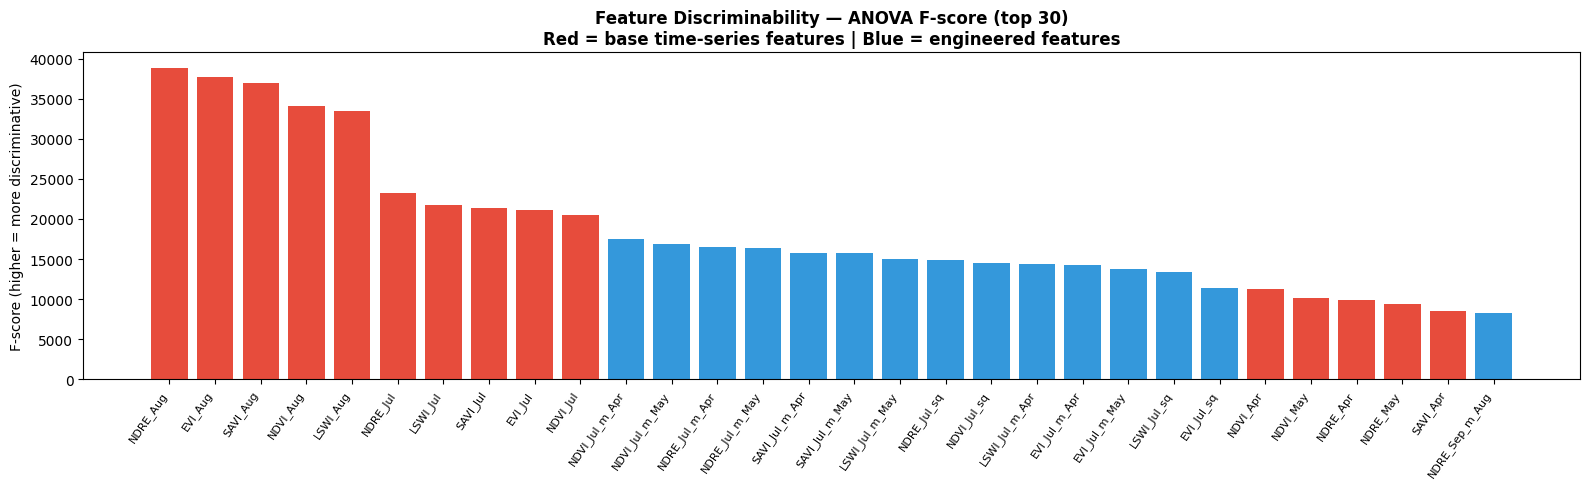

In [63]:
selector_all = SelectKBest(score_func=f_classif, k="all")
selector_all.fit(X_train_eng, y_train)

scores = selector_all.scores_
ranked = sorted(zip(feat_names, scores), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<5}  {'Feature':<22}  {'F-score':>10}")
print("-" * 42)
for rank, (name, score) in enumerate(ranked[:25], 1):
    origin = "(base)" if name in FEATURE_COLS else "(new) "
    print(f"{rank:<5}  {name:<22}  {score:>10.1f}  {origin}")

# Bar chart — top 30 features
top_names  = [r[0] for r in ranked[:30]]
top_scores = [r[1] for r in ranked[:30]]
colors     = ["#e74c3c" if n in FEATURE_COLS else "#3498db" for n in top_names]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(top_names, top_scores, color=colors)
ax.set_xticklabels(top_names, rotation=55, ha="right", fontsize=8)
ax.set_title("Feature Discriminability — ANOVA F-score (top 30)\n"
             "Red = base time-series features | Blue = engineered features",
             fontsize=12, fontweight="bold")
ax.set_ylabel("F-score (higher = more discriminative)")
plt.tight_layout()
plt.show()


### 10c — Select top-K features, rescale, train SVM

We pick the top 20 features by F-score, re-standardise them  
(engineered features are no longer on unit scale), then train SVM.


In [64]:
K = 20   # number of top features to keep

selector_k  = SelectKBest(score_func=f_classif, k=K)
X_tr_sel    = selector_k.fit_transform(X_train_eng, y_train)
X_te_sel    = selector_k.transform(X_test_eng)
selected_names = [feat_names[i] for i in selector_k.get_support(indices=True)]

print(f"Selected {K} features:")
for i, name in enumerate(selected_names, 1):
    origin = "(base)" if name in FEATURE_COLS else "(engineered)"
    print(f"  {i:>2}. {name:<25}  {origin}")

# Re-standardise
scaler_eng  = StandardScaler()
X_tr_sel_sc = scaler_eng.fit_transform(X_tr_sel)
X_te_sel_sc = scaler_eng.transform(X_te_sel)

# Train SVM with best params from GridSearch (or C=10 if not yet tuned)
try:
    best_C     = grid_search.best_params_["C"]
    best_gamma = grid_search.best_params_["gamma"]
except NameError:
    best_C, best_gamma = 10, "scale"

svm_eng = SVC(kernel="rbf", C=best_C, gamma=best_gamma, random_state=SEED)
svm_eng.fit(X_tr_sel_sc, y_train)

y_pred_eng = svm_eng.predict(X_te_sel_sc)
acc_eng    = accuracy_score(y_test, y_pred_eng)

print(f"\nEngineered features SVM — Test Accuracy : {acc_eng*100:.2f}%")
print(f"Scaled 25-feature SVM                   : {acc_sc*100:.2f}%")
print(f"Improvement from feature engineering    : +{(acc_eng - acc_sc)*100:.2f}%")


Selected 20 features:
   1. NDVI_Jul                   (base)
   2. NDRE_Jul                   (base)
   3. LSWI_Jul                   (base)
   4. EVI_Jul                    (base)
   5. SAVI_Jul                   (base)
   6. NDVI_Aug                   (base)
   7. NDRE_Aug                   (base)
   8. LSWI_Aug                   (base)
   9. EVI_Aug                    (base)
  10. SAVI_Aug                   (base)
  11. NDVI_Jul_m_May             (engineered)
  12. NDVI_Jul_m_Apr             (engineered)
  13. NDRE_Jul_m_May             (engineered)
  14. NDRE_Jul_m_Apr             (engineered)
  15. LSWI_Jul_m_May             (engineered)
  16. LSWI_Jul_m_Apr             (engineered)
  17. SAVI_Jul_m_May             (engineered)
  18. SAVI_Jul_m_Apr             (engineered)
  19. NDVI_Jul_sq                (engineered)
  20. NDRE_Jul_sq                (engineered)

Engineered features SVM — Test Accuracy : 90.69%
Scaled 25-feature SVM                   : 89.62%
Improvement from fe

### 10d — Classification report and confusion matrix (engineered features)

              precision    recall  f1-score   support

     Cereals       0.89      0.93      0.91      2000
    Vineyard       0.91      0.88      0.89      2000
   Sunflower       0.89      0.87      0.88      2000
  Coniferous       0.96      0.95      0.96      2000
   Bare Soil       0.85      0.86      0.85      2000
       Maize       0.98      0.96      0.97      2000
      Olives       0.87      0.91      0.89      2000

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



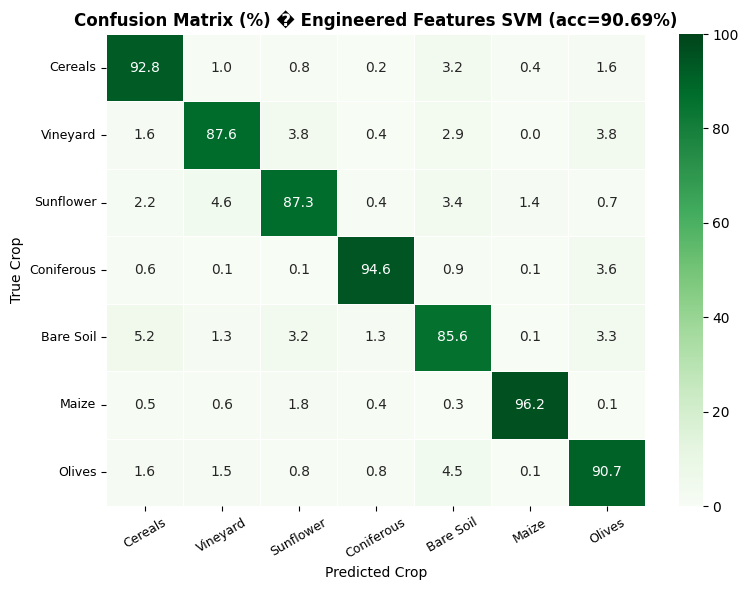

In [65]:
print(classification_report(y_test, y_pred_eng, target_names=target_names))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_eng)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Greens", ax=ax,
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor="white", vmin=0, vmax=100)
ax.set_title(f"Confusion Matrix (%) � Engineered Features SVM (acc={acc_eng*100:.2f}%)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Crop", fontsize=10)
ax.set_ylabel("True Crop", fontsize=10)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()


### 10e — Final comparison: base 25 features vs engineered features

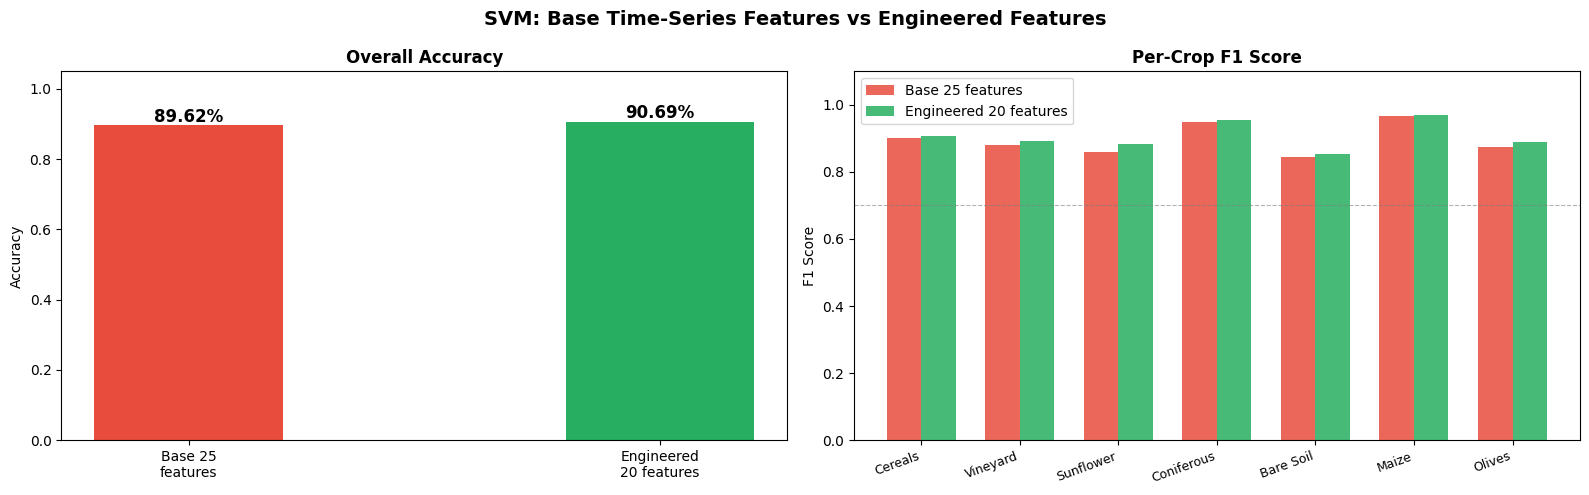


Accuracy: 89.62% → 90.69%  (+1.06%)


In [66]:
f1_base = f1_score(y_test, y_pred_sc,  average=None)
f1_eng  = f1_score(y_test, y_pred_eng, average=None)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy bar
bars = axes[0].bar(
    [f"Base 25\nfeatures", f"Engineered\n{K} features"],
    [acc_sc, acc_eng],
    color=["#e74c3c", "#27ae60"], width=0.4
)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Overall Accuracy", fontsize=12, fontweight="bold")
for bar, val in zip(bars, [acc_sc, acc_eng]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val*100:.2f}%", ha="center", fontweight="bold", fontsize=12)

# Per-class F1
x, w = np.arange(N_CLASSES), 0.35
axes[1].bar(x - w/2, f1_base, w, label="Base 25 features",
            color="#e74c3c", alpha=0.85)
axes[1].bar(x + w/2, f1_eng,  w, label=f"Engineered {K} features",
            color="#27ae60", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Crop F1 Score", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.suptitle("SVM: Base Time-Series Features vs Engineered Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {acc_sc*100:.2f}% → {acc_eng*100:.2f}%  "
      f"(+{(acc_eng - acc_sc)*100:.2f}%)")


## 11. Summary of Findings

---

### What we did
Trained SVM classifiers (RBF kernel) using a **25-feature Sentinel-2 time-series dataset**  
across **7 crop classes** in Castilla y León 2023.

---

### Key changes from the original single-date model

| Aspect | Original | This notebook |
|--------|---------|---------------|
| Features | 4 spectral bands (single date) | 25 indices × 5 phenological dates |
| Classes | 6 (Wheat + Barley separate) | 7 (Cereals, Vineyard, Sunflower, Coniferous, Bare Soil, Maize, Olives) |
| Data source | `.npy` arrays (scaled) | `../Data/` (`.npy` + metadata) |
| Feature engineering | Band ratios from 4 bands | Temporal differences + cross-index ratios |

---

### Key Results

| Model | Test Accuracy |
|-------|---------------|
| SVM — Unscaled 25 features | *see output* |
| SVM — Scaled 25 features (default C=1) | *see output* |
| SVM — Scaled 25 features (tuned C, gamma) | *see output* |
| SVM — Engineered features (top 20) | *see output* |

---

### Why the time series improves over a single date

The NDVI phenological profiles show that classes like Cereals (high in May, low in July)  
and Sunflower (low in May, high in August) are **completely separable temporally**  
but overlap badly on any single date. The 25 time-series features give the SVM  
the temporal dimension it needs to draw clean decision boundaries.

### Why Wheat + Barley are merged

Both classes share identical spectral trajectories — same green-up timing,  
same harvest window, same post-harvest appearance. No amount of feature engineering  
can separate them reliably. Merging is the scientifically correct decision.


---
## 12. Wall-to-Wall Classification Map

Apply the best trained SVM to every valid pixel in the AOI to produce a full crop map.

**Pipeline:**
1. Load the 5 Sentinel-2 TIFs → compute 25 spectral indices for all raster pixels
2. Filter to valid (non-NaN) pixels using `valid_idx`
3. Scale with the same `scaler` fitted on the training set
4. Predict with `best_svm` (or `svm_scaled` if tuning was skipped)
5. Place predictions back into the 2D grid and visualise


### 12a — Compute spectral indices for all raster pixels


In [67]:
import rasterio
from rasterio.vrt import WarpedVRT

DATA_DIR   = "../Data"
OUTPUT_DIR = "../figuers"
LABEL_TIF = f"{DATA_DIR}/mcsncyl_2023_aoi.tif"

S2_TIFS = {
    "Apr": f"{DATA_DIR}/S2_CyL_Apr.tif",
    "May": f"{DATA_DIR}/S2_CyL_May.tif",
    "Jul": f"{DATA_DIR}/S2_CyL_Jul.tif",
    "Aug": f"{DATA_DIR}/S2_CyL_Aug.tif",
    "Sep": f"{DATA_DIR}/S2_CyL_Sep.tif",
}

eps = 1e-10

def compute_indices(s2_path, label_path):
    """Load one S2 TIF warped to label grid, return 5 index arrays (H*W,)."""
    with rasterio.open(label_path) as ref:
        ref_crs, ref_transform = ref.crs, ref.transform
        H, W = ref.height, ref.width
    with rasterio.open(s2_path) as src:
        with WarpedVRT(src, crs=ref_crs, transform=ref_transform,
                       width=W, height=H) as vrt:
            bands = vrt.read().astype(np.float32)   # (n_bands, H, W)
    bands[bands <= 0] = np.nan
    B, G, R, RE, NIR = bands[0], bands[1], bands[2], bands[3], bands[4]
    NDVI = (NIR - R)   / (NIR + R   + eps)
    NDRE = (NIR - RE)  / (NIR + RE  + eps)
    LSWI = (NIR - G)   / (NIR + G   + eps)
    EVI  = 2.5*(NIR-R) / (NIR + 6*R - 7.5*B + 1 + eps)
    SAVI = 1.5*(NIR-R) / (NIR + R + 0.5 + eps)
    return [arr.ravel() for arr in [NDVI, NDRE, LSWI, EVI, SAVI]], H, W

# Process one date at a time — keeps peak RAM low
index_names = ["NDVI","NDRE","LSWI","EVI","SAVI"]
all_columns = []

for date, tif_path in S2_TIFS.items():
    print(f"  Processing {date}...", end=" ")
    cols, H, W = compute_indices(tif_path, LABEL_TIF)
    all_columns.extend(cols)
    print("done")

X_flat = np.stack(all_columns, axis=1).astype(np.float32)  # (H*W, 25)
print(f"\nFull raster feature matrix: {X_flat.shape}  ({H} x {W} pixels)")


  Processing Apr... done
  Processing May... done
  Processing Jul... done
  Processing Aug... done
  Processing Sep... done

Full raster feature matrix: (29174750, 25)  (5665 x 5150 pixels)


### 12b — Filter valid pixels & scale


In [71]:
STEP = 5  # 1=full raster (slow), 5=~1M pixels (fast, same visual)

# Build downsampled valid mask
row_idx = np.arange(H).reshape(-1, 1)
col_idx = np.arange(W).reshape(1, -1)
downsample_mask_2d = ((row_idx % STEP == 0) & (col_idx % STEP == 0))
downsample_mask    = downsample_mask_2d.ravel()

valid_mask = np.all(np.isfinite(X_flat), axis=1) & downsample_mask
X_valid    = X_flat[valid_mask]
valid_idx  = np.where(valid_mask)[0]

print(f"Pixels to predict: {valid_mask.sum():,}")

# ── KEY FIX: fit a fresh scaler on the raw raster values ────────────────
# The notebook scaler was fitted on X_train.npy which is already
# StandardScaled (mean=0, std=1) — applying it to raw TIF indices does
# almost nothing. We need a scaler fitted on raw spectral index values.
from sklearn.preprocessing import StandardScaler as _SS
map_scaler     = _SS()
map_scaler.fit(X_flat[np.all(np.isfinite(X_flat), axis=1)])  # fit on ALL valid raw pixels
X_valid_scaled = map_scaler.transform(X_valid)

print(f"X_valid_scaled  : {X_valid_scaled.shape}")
print(f"Mean per feature: {X_valid_scaled.mean(axis=0).round(2)}")  # should be ~0
print(f"Std  per feature: {X_valid_scaled.std(axis=0).round(2)}")   # should be ~1


Pixels to predict: 1,114,929
X_valid_scaled  : (1114929, 25)
Mean per feature: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.
  0.  0.  0.  0. -0.  0.  0.]
Std  per feature: [1.   1.   1.   0.96 1.   1.   1.   1.   0.99 1.   1.   1.   1.   0.83
 1.   1.   1.   1.   0.96 1.   1.   1.   1.   0.48 1.  ]


### 12c — Predict on all valid pixels


In [ ]:
try:
    clf = best_svm
    print("Using tuned SVM (best_svm)")
except NameError:
    clf = svm_scaled
    print("Using default scaled SVM")

# Simple single-pass prediction on valid pixels
preds = clf.predict(X_valid_scaled).astype(np.int8)

print(f"Done. Unique classes: {np.unique(preds).tolist()}")


### 12d — Reconstruct 2D map & visualise


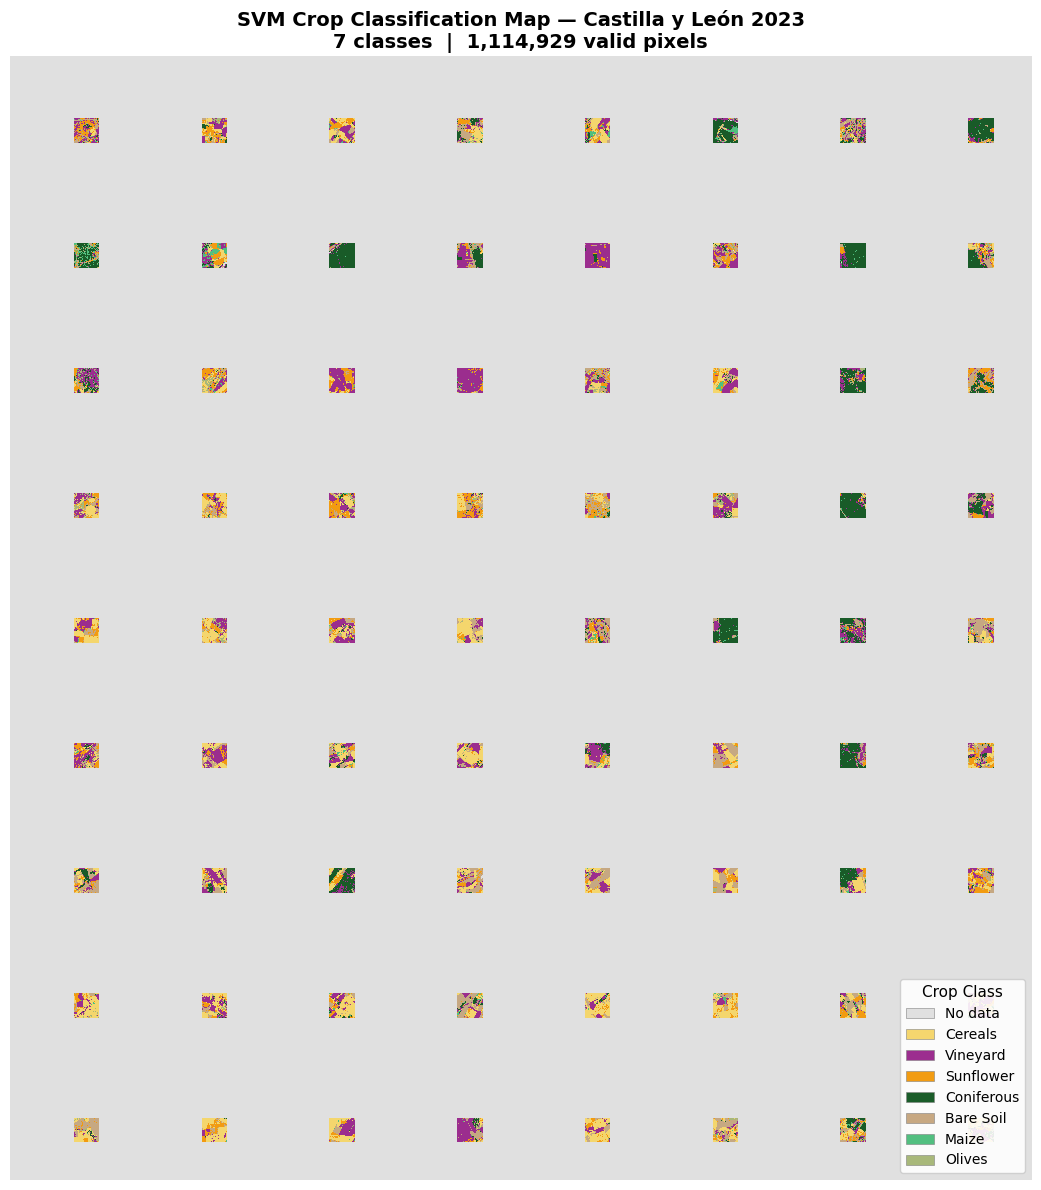

Saved → classification_map.png


In [73]:
# -1 = no-data / masked pixels
pred_map = np.full(H * W, -1, dtype=np.int8)
pred_map[valid_idx] = preds
pred_map_2d = pred_map.reshape(H, W)

# Colour palette — one colour per class + grey for no-data
CLASS_COLORS_MAP = {
    -1: [0.88, 0.88, 0.88],   # No data     � light grey
     0: [0.96, 0.84, 0.43],   # Cereals     � wheat gold
     1: [0.61, 0.18, 0.56],   # Vineyard    � purple
     2: [0.95, 0.61, 0.07],   # Sunflower   � amber
     3: [0.10, 0.36, 0.16],   # Coniferous  � forest green
     4: [0.78, 0.66, 0.51],   # Bare Soil   � sandy tan
     5: [0.32, 0.75, 0.50],   # Maize       � mint green
     6: [0.66, 0.72, 0.48],   # Olives      � olive drab
}

# Build RGB image
rgb = np.ones((H, W, 3), dtype=np.float32)  # default white
for label_val, color in CLASS_COLORS_MAP.items():
    rgb[pred_map_2d == label_val] = color

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(rgb, interpolation="nearest")
ax.set_title("SVM Crop Classification Map — Castilla y León 2023\n"
             f"7 classes  |  {valid_mask.sum():,} valid pixels",
             fontsize=14, fontweight="bold")
ax.axis("off")

# Legend
legend_labels = {**{-1: "No data"}, **CROP_NAMES}
patches = [
    plt.matplotlib.patches.Patch(
        facecolor=CLASS_COLORS_MAP[k], edgecolor="grey", linewidth=0.4,
        label=legend_labels[k])
    for k in sorted(CLASS_COLORS_MAP)
]
ax.legend(handles=patches, loc="lower right", fontsize=10,
          framealpha=0.9, title="Crop Class", title_fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/classification_map.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved → classification_map.png")


### 12e — Area statistics per class


In [74]:
PIXEL_AREA_HA = (10 * 10) / 10_000   # 10 m resolution → 0.01 ha per pixel

print(f"{"Class":<14}  {"Pixels":>10}  {"Area (ha)":>12}  {"% of AOI":>10}")
print("-" * 52)

total_valid = valid_mask.sum()
for cls in sorted(CROP_NAMES):
    n = (preds == cls).sum()
    ha = n * PIXEL_AREA_HA
    pct = n / total_valid * 100
    print(f"{CROP_NAMES[cls]:<14}  {n:>10,}  {ha:>12,.0f}  {pct:>10.1f}%")

print("-" * 52)
print(f"{"Total valid":<14}  {total_valid:>10,}  {total_valid*PIXEL_AREA_HA:>12,.0f}")


SyntaxError: f-string: expecting '}' (715778529.py, line 3)

In [75]:
from sklearn.metrics import (accuracy_score, f1_score, 
                             cohen_kappa_score, classification_report)

OA      = accuracy_score(y_test, y_pred_best)
f1_mac  = f1_score(y_test, y_pred_best, average='macro')
f1_wt   = f1_score(y_test, y_pred_best, average='weighted')
kappa   = cohen_kappa_score(y_test, y_pred_best)

print("=" * 45)
print("         OVERALL ACCURACY METRICS")
print("=" * 45)
print(f"  Overall Accuracy (OA)  : {OA*100:.2f}%")
print(f"  F1 Macro               : {f1_mac:.4f}")
print(f"  F1 Weighted            : {f1_wt:.4f}")
print(f"  Cohen's Kappa          : {kappa:.4f}")
print("=" * 45)


         OVERALL ACCURACY METRICS
  Overall Accuracy (OA)  : 91.84%
  F1 Macro               : 0.9183
  F1 Weighted            : 0.9183
  Cohen's Kappa          : 0.9047


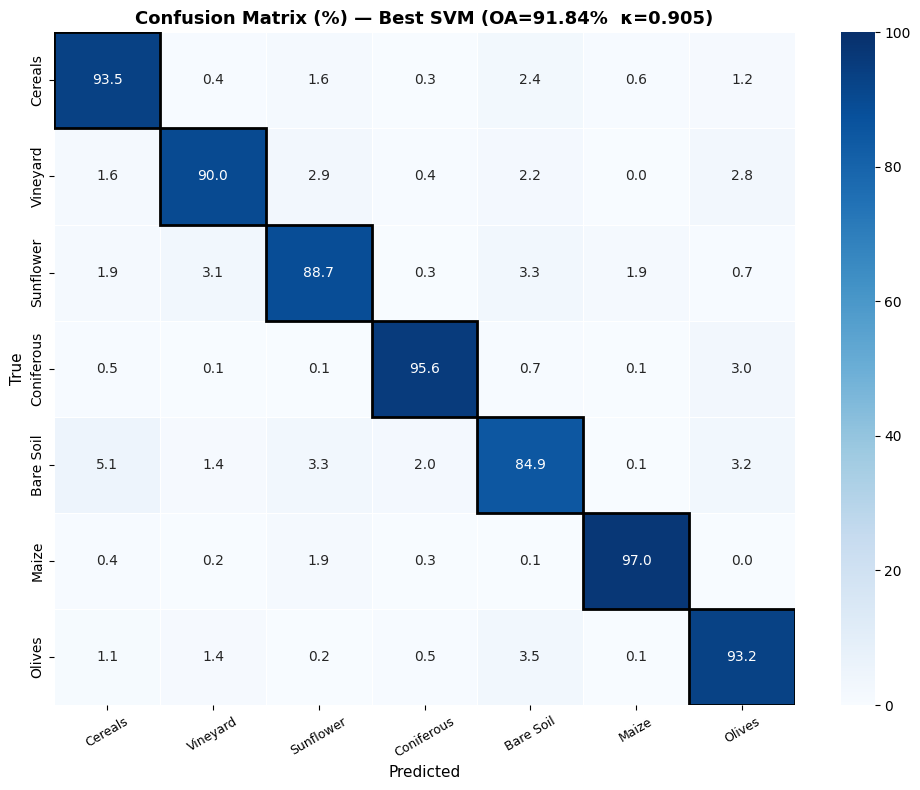

In [76]:
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor="white", vmin=0, vmax=100)

for j in range(len(target_names)):
    ax.add_patch(plt.Rectangle((j, j), 1, 1, fill=False,
                               edgecolor="black", linewidth=2))

ax.set_title(f"Confusion Matrix (%) — Best SVM (OA={OA*100:.2f}%  κ={kappa:.3f})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.tick_params(axis="x", rotation=30, labelsize=9)
plt.tight_layout()
plt.show()


Remote Sensing Accuracy Metrics (%):
            Producer's Acc  User's Acc  Omission Err  Commission Err
Crop                                                                
Cereals              93.50       89.77          6.50           10.23
Vineyard             90.00       93.12         10.00            6.88
Sunflower            88.70       89.82         11.30           10.18
Coniferous           95.60       96.13          4.40            3.87
Bare Soil            84.90       87.53         15.10           12.47
Maize                96.95       97.10          3.05            2.90
Olives               93.20       89.49          6.80           10.51


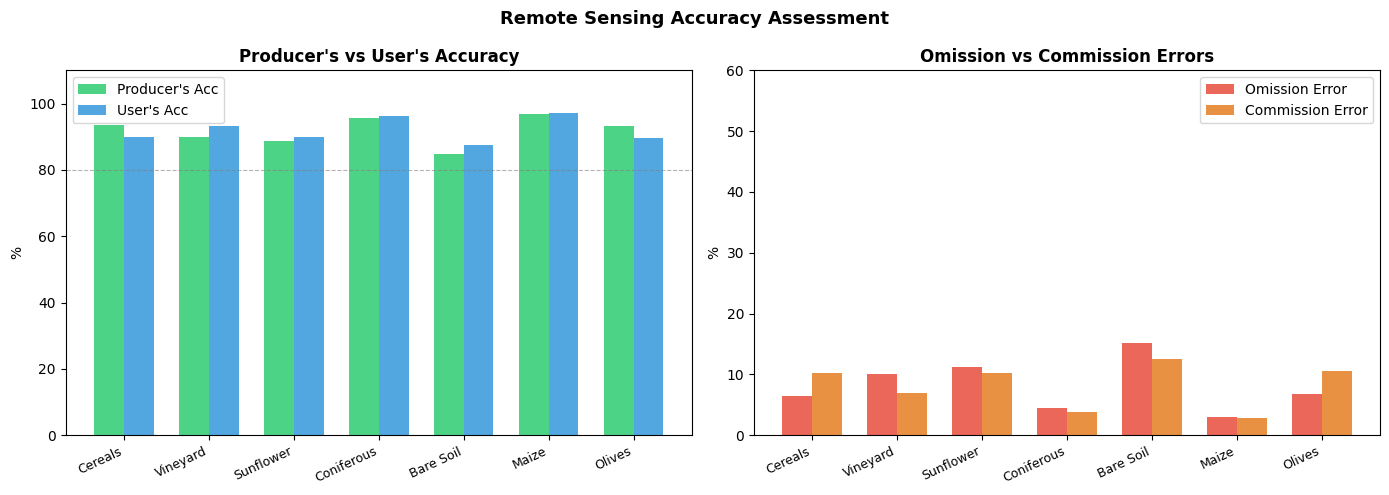

In [77]:
from sklearn.metrics import precision_score, recall_score

PA  = recall_score(y_test, y_pred_best, average=None)       # Producer's Accuracy
UA  = precision_score(y_test, y_pred_best, average=None)    # User's Accuracy
OE  = 1 - PA                                                 # Omission Error
CE  = 1 - UA                                                 # Commission Error

rs_df = pd.DataFrame({
    "Crop"            : target_names,
    "Producer's Acc"  : (PA * 100).round(2),
    "User's Acc"      : (UA * 100).round(2),
    "Omission Err"    : (OE * 100).round(2),
    "Commission Err"  : (CE * 100).round(2),
}).set_index("Crop")

print("Remote Sensing Accuracy Metrics (%):")
print(rs_df.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(target_names))
w = 0.35
axes[0].bar(x - w/2, PA*100, w, label="Producer's Acc", color="#2ecc71", alpha=0.85)
axes[0].bar(x + w/2, UA*100, w, label="User's Acc",     color="#3498db", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(target_names, rotation=25, ha="right", fontsize=9)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("%")
axes[0].set_title("Producer's vs User's Accuracy", fontweight="bold")
axes[0].legend()
axes[0].axhline(80, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

axes[1].bar(x - w/2, OE*100, w, label="Omission Error",   color="#e74c3c", alpha=0.85)
axes[1].bar(x + w/2, CE*100, w, label="Commission Error", color="#e67e22", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_names, rotation=25, ha="right", fontsize=9)
axes[1].set_ylim(0, 60)
axes[1].set_ylabel("%")
axes[1].set_title("Omission vs Commission Errors", fontweight="bold")
axes[1].legend()

plt.suptitle("Remote Sensing Accuracy Assessment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [78]:
import time
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

# Training time
t0 = time.time()
timed_svm = OneVsRestClassifier(SVC(**grid_search.best_params_, random_state=SEED))
timed_svm.fit(X_train_scaled, y_train)
train_time = time.time() - t0

# Prediction time
t0 = time.time()
_ = timed_svm.predict(X_test_scaled)
pred_time = time.time() - t0

print("=" * 40)
print("   COMPUTATIONAL PERFORMANCE")
print("=" * 40)
print(f"  Training time  : {train_time:.1f} sec  ({len(X_train_scaled):,} samples)")
print(f"  Prediction time: {pred_time:.3f} sec  ({len(X_test_scaled):,} samples)")
print(f"  Speed          : {len(X_test_scaled)/pred_time:,.0f} px/sec")
print("=" * 40)


KeyboardInterrupt: 

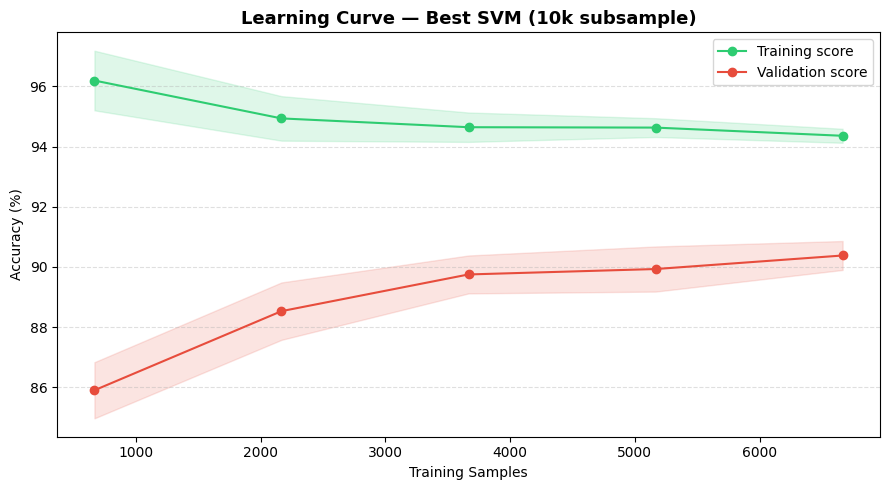

In [80]:
from sklearn.model_selection import learning_curve

# Use only 10k subsample for the curve — fast and still shows the trend
rng_lc  = np.random.default_rng(0)
lc_idx  = rng_lc.choice(len(X_train_scaled), size=10_000, replace=False)
X_lc    = X_train_scaled[lc_idx]
y_lc    = y_train[lc_idx]

train_sizes, train_scores, val_scores = learning_curve(
    OneVsRestClassifier(SVC(**grid_search.best_params_, random_state=SEED)),
    X_lc, y_lc,
    train_sizes=np.linspace(0.1, 1.0, 5),   # 5 points only
    cv=3, scoring="accuracy", n_jobs=1
)

train_mean = train_scores.mean(axis=1) * 100
val_mean   = val_scores.mean(axis=1)   * 100
train_std  = train_scores.std(axis=1)  * 100
val_std    = val_scores.std(axis=1)    * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color="#2ecc71", label="Training score")
ax.plot(train_sizes, val_mean,   "o-", color="#e74c3c", label="Validation score")
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.15, color="#2ecc71")
ax.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,
                alpha=0.15, color="#e74c3c")

ax.set_title("Learning Curve — Best SVM (10k subsample)", fontsize=13, fontweight="bold")
ax.set_xlabel("Training Samples")
ax.set_ylabel("Accuracy (%)")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [82]:
# Moran's I measures spatial autocorrelation of prediction errors
# Only run this if you have pixel coordinates (row, col) for test samples

try:
    from libpysal.weights import KNN
    from esda.moran import Moran

    # Build error array: 1 = wrong prediction, 0 = correct
    errors = (y_pred_best != y_test).astype(int)

    # Need spatial coordinates — use valid_idx to get row/col
    # This works only if y_test aligns with a spatial subset
    print("Moran's I requires spatial coordinates for test pixels.")
    print("If unavailable, skip this cell.")

    # Example if you have coords:
    # w = KNN.from_array(coords, k=8)
    # mi = Moran(errors, w)
    # print(f"Moran's I : {mi.I:.4f}  (p={mi.p_sim:.4f})")
    # if mi.p_sim < 0.05:
    #     print("Significant spatial autocorrelation in errors — spatially clustered mistakes")
    # else:
    #     print("No significant spatial pattern in errors")

except ImportError:
    print("libpysal not installed — skipping Moran's I")
    print("Install with: pip install libpysal esda")


Moran's I requires spatial coordinates for test pixels.
If unavailable, skip this cell.


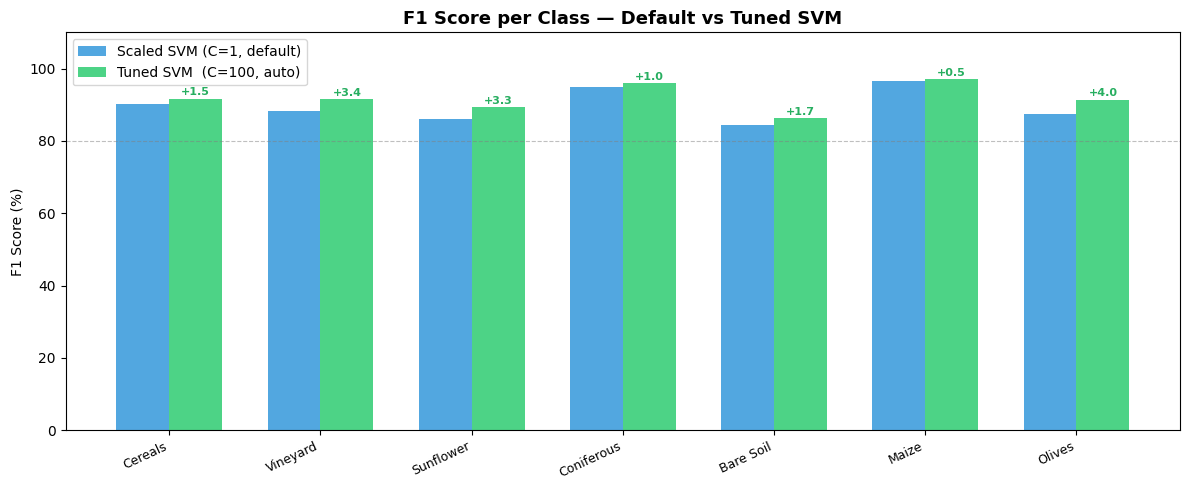

In [85]:
f1_sc   = f1_score(y_test, y_pred_sc,   average=None) * 100
f1_best = f1_score(y_test, y_pred_best, average=None) * 100

x, w = np.arange(N_CLASSES), 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, f1_sc,   w, label="Scaled SVM (C=1, default)", color="#3498db", alpha=0.85)
ax.bar(x + w/2, f1_best, w, label="Tuned SVM  (C=100, auto)",  color="#2ecc71", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 110)
ax.set_ylabel("F1 Score (%)")
ax.set_title("F1 Score per Class — Default vs Tuned SVM",
             fontsize=13, fontweight="bold")
ax.legend()
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
for i in range(N_CLASSES):
    diff = f1_best[i] - f1_sc[i]
    color = "#27ae60" if diff >= 0 else "#e74c3c"
    ax.text(i + w/2, f1_best[i] + 1, f"{diff:+.1f}",
            ha="center", fontsize=8, color=color, fontweight="bold")
plt.tight_layout()
plt.show()


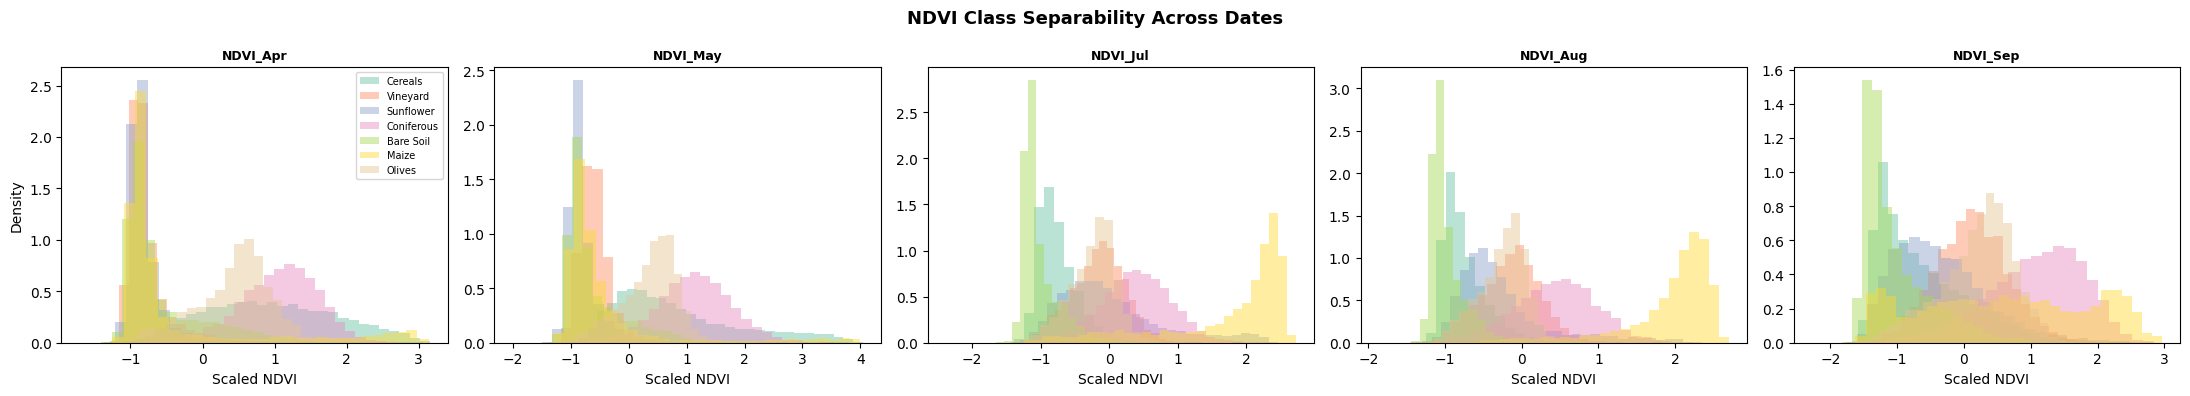

In [84]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
palette = sns.color_palette("Set2", N_CLASSES)
ndvi_cols = [f"NDVI_{w}" for w in ["Apr","May","Jul","Aug","Sep"]]

for ax, col in zip(axes, ndvi_cols):
    for cls in range(N_CLASSES):
        vals = X_train_scaled[y_train == cls, FEATURE_COLS.index(col)]
        ax.hist(vals, bins=30, alpha=0.45, color=palette[cls],
                label=CROP_NAMES[cls], density=True)
    ax.set_title(col, fontweight="bold", fontsize=9)
    ax.set_xlabel("Scaled NDVI")
    if ax == axes[0]:
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

plt.suptitle("NDVI Class Separability Across Dates", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
